# User Input Explanations for Quantitative DDI LD50 Prediction

This notebook allows a user to input two compounds using either common names or SMILES.
It then:
1. Resolves names to SMILES if needed
2. Converts both molecules into graph form
3. Loads the trained Phase 4 regression model
4. Predicts the mixture toxicity (pLD50)
5. Applies the selected XAI method
6. Visualizes important atoms using highlighted molecular graphs and bar plots
7. Generates a human-readable explanation

In [1]:
!pip install rdkit
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric
!pip install pubchempy

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import json
import copy
import random
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import (
    GCNConv, GINConv, GATv2Conv,
    global_mean_pool, global_add_pool,
    BatchNorm
)

from sklearn.preprocessing import StandardScaler

from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import Descriptors
from rdkit.Chem.Draw import rdMolDraw2D

import pubchempy as pcp

warnings.filterwarnings("ignore")
RDLogger.DisableLog('rdApp.*')

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Change this path to your local project folder
base_path = r"C:\Users\msi\Downloads\IRP Jupiter nb\Data"
processed_dir = os.path.join(base_path, "processed_graphs")

best_reg_model_path = os.path.join(processed_dir, "best_ddi_reg_model.pt")
mixture_scaler_path = os.path.join(processed_dir, "mixture_toxicity_scaler.pkl")

# Add these two paths so the scaler can be rebuilt if joblib fails
mixture_raw_path = os.path.join(processed_dir, "unified_mixture_toxicity.pt")
mixture_csv_path = os.path.join(base_path, "unified_mixture_toxicity_processed.csv")

output_dir = os.path.join(processed_dir, "user_input_explanations")
os.makedirs(output_dir, exist_ok=True)

print("Model path:", best_reg_model_path)
print("Scaler path:", mixture_scaler_path)
print("Raw mixture graph path:", mixture_raw_path)
print("Raw mixture csv path:", mixture_csv_path)
print("Output dir:", output_dir)

Using device: cuda
Model path: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\best_ddi_reg_model.pt
Scaler path: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\mixture_toxicity_scaler.pkl
Raw mixture graph path: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\unified_mixture_toxicity.pt
Raw mixture csv path: C:\Users\msi\Downloads\IRP Jupiter nb\Data\unified_mixture_toxicity_processed.csv
Output dir: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\user_input_explanations


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

## Graph feature functions

In [5]:
def atom_features(atom):
    symbols = ['C', 'N', 'O', 'S', 'F', 'P', 'Cl', 'Br', 'I', 'B']
    symbol = atom.GetSymbol()
    symbol_vec = [1.0 if symbol == s else 0.0 for s in symbols]

    degree = atom.GetDegree()
    degree_vec = [0.0] * 7
    degree_vec[min(degree, 6)] = 1.0

    formal_charge = atom.GetFormalCharge()

    hyb = atom.GetHybridization()
    hyb_vec = [
        1.0 if hyb == Chem.rdchem.HybridizationType.SP else 0.0,
        1.0 if hyb == Chem.rdchem.HybridizationType.SP2 else 0.0,
        1.0 if hyb == Chem.rdchem.HybridizationType.SP3 else 0.0
    ]

    is_aromatic = 1.0 if atom.GetIsAromatic() else 0.0
    mass = atom.GetMass()
    num_h = atom.GetTotalNumHs()

    features = symbol_vec + degree_vec + [formal_charge] + hyb_vec + [is_aromatic, mass, num_h]
    return np.array(features, dtype=np.float32)


def bond_features(bond):
    bond_type = bond.GetBondType()
    bond_type_vec = [
        1.0 if bond_type == Chem.rdchem.BondType.SINGLE else 0.0,
        1.0 if bond_type == Chem.rdchem.BondType.DOUBLE else 0.0,
        1.0 if bond_type == Chem.rdchem.BondType.TRIPLE else 0.0,
        1.0 if bond_type == Chem.rdchem.BondType.AROMATIC else 0.0
    ]
    is_conjugated = 1.0 if bond.GetIsConjugated() else 0.0
    is_in_ring = 1.0 if bond.IsInRing() else 0.0

    return np.array(bond_type_vec + [is_conjugated, is_in_ring], dtype=np.float32)

## Convert SMILES to graph

In [6]:
from torch_geometric.data import Data

def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    atom_feats = [atom_features(atom) for atom in mol.GetAtoms()]
    x = torch.tensor(np.array(atom_feats), dtype=torch.float)

    edge_indices = []
    edge_feats = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        feats = bond_features(bond)

        edge_indices += [[i, j], [j, i]]
        edge_feats += [feats, feats]

    if len(edge_indices) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, 6), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(np.array(edge_feats), dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    return data


def prepare_single_graph(g, device):
    g = g.clone().to(device)
    g.batch = torch.zeros(g.x.size(0), dtype=torch.long, device=device)
    return g

## Encoder classes

In [7]:
class GCNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        return torch.cat([mean_pool, sum_pool], dim=1)


class GINEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, dropout=0.2):
        super().__init__()

        mlp1 = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        mlp2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        mlp3 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.conv1 = GINConv(mlp1)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GINConv(mlp2)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GINConv(mlp3)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        return torch.cat([mean_pool, sum_pool], dim=1)


class GATv2Encoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, heads=4, dropout=0.2):
        super().__init__()
        self.conv1 = GATv2Conv(in_dim, hidden_dim // heads, heads=heads, dropout=dropout)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, dropout=dropout)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, concat=True, dropout=dropout)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        return torch.cat([mean_pool, sum_pool], dim=1)

## Regression head classes

In [8]:
class DualEncoderConcatRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        fused = torch.cat([emb_a, emb_b], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderConcatProdRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        prod = emb_a * emb_b
        fused = torch.cat([emb_a, emb_b, prod], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderBilinearConcatProdRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.bilinear = nn.Bilinear(emb_dim, emb_dim, emb_dim)
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 4, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        prod = emb_a * emb_b
        bilinear_term = self.bilinear(emb_a, emb_b)
        fused = torch.cat([emb_a, emb_b, prod, bilinear_term], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderAbsDiffConcatRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        abs_diff = torch.abs(emb_a - emb_b)
        fused = torch.cat([emb_a, emb_b, abs_diff], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderSymmetricFusionRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        emb_sum = emb_a + emb_b
        abs_diff = torch.abs(emb_a - emb_b)
        prod = emb_a * emb_b
        fused = torch.cat([emb_sum, abs_diff, prod], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderGatedFusionRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.gate = nn.Sequential(
            nn.Linear(emb_dim * 2, emb_dim),
            nn.Sigmoid()
        )
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        gate = self.gate(torch.cat([emb_a, emb_b], dim=1))
        fused_main = gate * emb_a + (1.0 - gate) * emb_b
        prod = emb_a * emb_b
        fused = torch.cat([fused_main, prod], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused

## Build model from saved metadata

In [9]:
def build_pretrained_encoder(encoder_meta):
    model_name = encoder_meta["model_name"]
    in_dim = encoder_meta["node_feat_dim"]
    hidden_dim = encoder_meta["hidden_dim"]
    dropout = encoder_meta["dropout"]

    if model_name == "GCN":
        encoder = GCNEncoder(in_dim, hidden_dim, dropout)
    elif model_name == "GIN":
        encoder = GINEncoder(in_dim, hidden_dim, dropout)
    elif model_name == "GATv2":
        encoder = GATv2Encoder(in_dim, hidden_dim, dropout=dropout)
    else:
        raise ValueError(f"Unknown encoder type: {model_name}")

    encoder.load_state_dict(encoder_meta["encoder_state_dict"])
    return encoder


def build_regression_model(model_name, encoder_meta, dropout=0.2):
    encoder = build_pretrained_encoder(encoder_meta)

    if model_name == "ConcatRegressor":
        return DualEncoderConcatRegressor(encoder, dropout=dropout)
    elif model_name == "ConcatProdRegressor":
        return DualEncoderConcatProdRegressor(encoder, dropout=dropout)
    elif model_name == "BilinearConcatProdRegressor":
        return DualEncoderBilinearConcatProdRegressor(encoder, dropout=dropout)
    elif model_name == "AbsDiffConcatRegressor":
        return DualEncoderAbsDiffConcatRegressor(encoder, dropout=dropout)
    elif model_name == "SymmetricFusionRegressor":
        return DualEncoderSymmetricFusionRegressor(encoder, dropout=dropout)
    elif model_name == "GatedFusionRegressor":
        return DualEncoderGatedFusionRegressor(encoder, dropout=dropout)
    else:
        raise ValueError(f"Unknown model name: {model_name}")

## Safe scaler loader helpers

In [10]:
from sklearn.preprocessing import StandardScaler

def load_scaler_safely(scaler_path, raw_graph_path=None, raw_csv_path=None, target_col="Target_neglog_molkg"):
    """
    Try to load the saved scaler.
    If that fails because of environment incompatibility, rebuild it from raw targets.
    Priority:
    1. Load joblib scaler directly
    2. Rebuild from unified_mixture_toxicity.pt
    3. Rebuild from unified_mixture_toxicity_processed.csv
    """
    # Try normal joblib load first
    try:
        scaler = joblib.load(scaler_path)
        print("Scaler loaded successfully from joblib file.")
        return scaler
    except Exception as e:
        print(f"Direct scaler load failed: {e}")
        print("Trying to rebuild scaler from raw targets...")

    # Try rebuilding from raw graph file
    if raw_graph_path is not None and os.path.exists(raw_graph_path):
        try:
            raw_data = torch.load(raw_graph_path, map_location="cpu", weights_only=False)
            raw_targets = raw_data[2]

            if torch.is_tensor(raw_targets):
                raw_targets = raw_targets.view(-1).cpu().numpy().reshape(-1, 1)
            else:
                raw_targets = np.array(raw_targets, dtype=float).reshape(-1, 1)

            scaler = StandardScaler()
            scaler.fit(raw_targets)

            print("Scaler rebuilt successfully from unified_mixture_toxicity.pt")
            print("Recovered mean:", float(scaler.mean_[0]))
            print("Recovered std:", float(scaler.scale_[0]))
            return scaler
        except Exception as e:
            print(f"Rebuild from raw graph file failed: {e}")

    # Try rebuilding from CSV
    if raw_csv_path is not None and os.path.exists(raw_csv_path):
        try:
            df = pd.read_csv(raw_csv_path)

            if target_col not in df.columns:
                raise ValueError(f"Column '{target_col}' not found in CSV.")

            raw_targets = pd.to_numeric(df[target_col], errors="coerce").dropna().values.reshape(-1, 1)

            scaler = StandardScaler()
            scaler.fit(raw_targets)

            print("Scaler rebuilt successfully from unified_mixture_toxicity_processed.csv")
            print("Recovered mean:", float(scaler.mean_[0]))
            print("Recovered std:", float(scaler.scale_[0]))
            return scaler
        except Exception as e:
            print(f"Rebuild from CSV failed: {e}")

    raise RuntimeError(
        "Could not load or rebuild the scaler. "
        "Please make sure either the scaler file, unified_mixture_toxicity.pt, "
        "or unified_mixture_toxicity_processed.csv is available."
    )

## Load saved best model and scaler

In [11]:
phase4_meta = torch.load(best_reg_model_path, map_location="cpu", weights_only=False)

print("Selected model:", phase4_meta["model_name"])
print("Best validation MAE:", phase4_meta["best_val_mae"])
print("Best epoch:", phase4_meta["best_epoch"])

model = build_regression_model(
    model_name=phase4_meta["model_name"],
    encoder_meta=phase4_meta["encoder_meta"],
    dropout=phase4_meta["dropout"]
).to(device)

model.load_state_dict(phase4_meta["model_state_dict"])
model.eval()
print("Model loaded successfully.")

# Safe scaler load or rebuild
mixture_scaler = load_scaler_safely(
    scaler_path=mixture_scaler_path,
    raw_graph_path=mixture_raw_path,
    raw_csv_path=mixture_csv_path,
    target_col="Target_neglog_molkg"
)

print("Model and scaler ready.")

Selected model: SymmetricFusionRegressor
Best validation MAE: 0.308227
Best epoch: 49
Model loaded successfully.
Direct scaler load failed: No module named 'numpy._core'
Trying to rebuild scaler from raw targets...
Scaler rebuilt successfully from unified_mixture_toxicity.pt
Recovered mean: 1.792277921231834
Recovered std: 0.6912961627657191
Model and scaler ready.


## Name/SMILES resolution helpers

In [12]:
resolved_name_cache = {}

def looks_like_name(text):
    """
    Heuristic: if input contains spaces, lowercase words, hyphens in name-like form,
    or alphabetic patterns that are unlikely to be SMILES, treat it as a name first.
    """
    text = str(text).strip()

    # very common signs of a chemical name
    if " " in text:
        return True

    lowered = text.lower()

    # name-like patterns
    common_name_tokens = [
        "acid", "amine", "nitrile", "alcohol", "ether", "ketone", "aldehyde",
        "benzene", "morpholine", "pyridine", "phenol", "amide", "ester",
        "ene", "yne", "prop", "but", "ethyl", "methyl", "chloro", "bromo",
        "fluoro", "iodo"
    ]
    if any(tok in lowered for tok in common_name_tokens):
        return True

    # if it has lowercase alphabetic words and not obvious SMILES brackets/ring markers
    if any(c.isalpha() for c in text):
        smiles_like_chars = set("BCNOFPSIbcnoprs[]=#()+-@\\/1234567890")
        if any(c not in smiles_like_chars for c in text):
            return True

    return False


def is_valid_smiles(text):
    """
    Check SMILES validity without printing RDKit parse errors.
    """
    try:
        text = str(text).strip()
        if not text:
            return False

        # suppress RDKit error spam during trial parsing
        mol = Chem.MolFromSmiles(text)
        return mol is not None
    except:
        return False


def canonicalize_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, canonical=True)


def name_to_smiles(name):
    """
    Resolve a common chemical name to canonical SMILES using PubChem.
    """
    try:
        compounds = pcp.get_compounds(name, "name")
        if compounds and len(compounds) > 0:
            smi = compounds[0].canonical_smiles
            if smi:
                return canonicalize_smiles(smi)
    except:
        pass
    return None


def smiles_to_common_name(smiles):
    if smiles in resolved_name_cache:
        return resolved_name_cache[smiles]

    try:
        compounds = pcp.get_compounds(smiles, namespace="smiles")
        if compounds and len(compounds) > 0:
            c = compounds[0]

            if hasattr(c, "iupac_name") and c.iupac_name:
                resolved_name_cache[smiles] = c.iupac_name
                return c.iupac_name

            try:
                syns = c.synonyms
                if syns and len(syns) > 0:
                    resolved_name_cache[smiles] = syns[0]
                    return syns[0]
            except:
                pass
    except:
        pass

    fallback = f"Compound_{smiles[:18]}..."
    resolved_name_cache[smiles] = fallback
    return fallback


def resolve_user_input(text):
    """
    Resolve user input safely.
    Strategy:
    1. If it looks like a common chemical name, try name lookup first.
    2. Otherwise try SMILES parsing first.
    3. Fall back to the other route if needed.
    """
    text = str(text).strip()

    if not text:
        raise ValueError("Empty input was provided.")

    # Case 1: looks like a common name -> try PubChem name lookup first
    if looks_like_name(text):
        smi = name_to_smiles(text)
        if smi is not None:
            return {
                "input": text,
                "smiles": smi,
                "name": text,
                "mode": "name"
            }

        # fallback to SMILES check
        if is_valid_smiles(text):
            smi = canonicalize_smiles(text)
            name = smiles_to_common_name(smi)
            return {
                "input": text,
                "smiles": smi,
                "name": name,
                "mode": "smiles"
            }

    # Case 2: try as SMILES first
    else:
        if is_valid_smiles(text):
            smi = canonicalize_smiles(text)
            name = smiles_to_common_name(smi)
            return {
                "input": text,
                "smiles": smi,
                "name": name,
                "mode": "smiles"
            }

        # fallback to name lookup
        smi = name_to_smiles(text)
        if smi is not None:
            return {
                "input": text,
                "smiles": smi,
                "name": text,
                "mode": "name"
            }

    raise ValueError(f"Could not resolve input: {text}")

## Prediction helpers

In [13]:
def predict_scaled(model, graph_a, graph_b):
    model.eval()
    with torch.no_grad():
        out, _ = model(graph_a, graph_b)
    return float(out.view(-1)[0].item())

def predict_original(model, graph_a, graph_b, scaler):
    pred_scaled = predict_scaled(model, graph_a, graph_b)
    pred_original = scaler.inverse_transform(np.array([[pred_scaled]])).flatten()[0]
    return float(pred_original)

def classify_toxicity_level(pred_pld50):
    if pred_pld50 >= 3.5:
        return "extremely high toxicity"
    elif pred_pld50 >= 3.0:
        return "very high toxicity"
    elif pred_pld50 >= 2.5:
        return "high toxicity"
    elif pred_pld50 >= 2.0:
        return "moderate toxicity"
    elif pred_pld50 >= 1.5:
        return "low toxicity"
    else:
        return "very low toxicity"

## XAI method

In [14]:
def normalize_importance(arr):
    arr = np.asarray(arr, dtype=float)
    if arr.max() > 0:
        arr = arr / arr.max()
    return arr

def explain_integrated_gradients(model, graph_a, graph_b, device, steps=50):
    """
    Integrated Gradients for a dual-encoder graph regression model.
    Baseline: zero feature vector for each atom.
    Attribution: accumulated gradient norm along the interpolation path,
    scaled by the input-baseline difference norm.
    """
    model.eval()

    # ── Drug A ───────────────────────────────────────────────────────────────
    x_a = graph_a.x.clone().detach().to(device)
    baseline_a = torch.zeros_like(x_a)
    imp_a = torch.zeros(x_a.size(0), device=device)

    for step in range(1, steps + 1):
        alpha = step / steps
        x_interp = (baseline_a + alpha * (x_a - baseline_a)).requires_grad_(True)

        g_a_interp = graph_a.clone().to(device)
        g_a_interp.x = x_interp

        out, _ = model(g_a_interp, graph_b)
        pred = out.view(-1)[0]
        pred.backward()

        if x_interp.grad is not None:
            imp_a += x_interp.grad.detach().norm(dim=1)

        model.zero_grad()

    # scale by (input − baseline) norm and average over steps
    imp_a = (imp_a / steps) * (x_a - baseline_a).norm(dim=1)
    imp_a = imp_a.cpu().numpy()

    # ── Drug B ───────────────────────────────────────────────────────────────
    x_b = graph_b.x.clone().detach().to(device)
    baseline_b = torch.zeros_like(x_b)
    imp_b = torch.zeros(x_b.size(0), device=device)

    for step in range(1, steps + 1):
        alpha = step / steps
        x_interp = (baseline_b + alpha * (x_b - baseline_b)).requires_grad_(True)

        g_b_interp = graph_b.clone().to(device)
        g_b_interp.x = x_interp

        out, _ = model(graph_a, g_b_interp)
        pred = out.view(-1)[0]
        pred.backward()

        if x_interp.grad is not None:
            imp_b += x_interp.grad.detach().norm(dim=1)

        model.zero_grad()

    imp_b = (imp_b / steps) * (x_b - baseline_b).norm(dim=1)
    imp_b = imp_b.cpu().numpy()

    return imp_a, imp_b

## Visualization helpers

In [15]:
def draw_molecule_with_importance(smiles, atom_importance, title="Molecule", out_path=None):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print("Invalid SMILES")
        return None

    atom_importance = normalize_importance(atom_importance)

    cmap = cm.get_cmap("OrRd")
    atom_colors = {}
    atom_radii = {}

    for i, score in enumerate(atom_importance):
        rgba = cmap(float(score))
        atom_colors[i] = (float(rgba[0]), float(rgba[1]), float(rgba[2]))
        atom_radii[i] = 0.25 + 0.35 * float(score)

    drawer = rdMolDraw2D.MolDraw2DCairo(700, 500)
    opts = drawer.drawOptions()

    for atom in mol.GetAtoms():
        idx = atom.GetIdx()
        opts.atomLabels[idx] = f"{atom.GetSymbol()}:{idx}"

    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer,
        mol,
        highlightAtoms=list(atom_colors.keys()),
        highlightAtomColors=atom_colors,
        highlightAtomRadii=atom_radii
    )
    drawer.FinishDrawing()

    png = drawer.GetDrawingText()

    if out_path is not None:
        with open(out_path, "wb") as f:
            f.write(png)

    temp_path = out_path if out_path is not None else "temp_molecule.png"
    if out_path is None:
        with open(temp_path, "wb") as f:
            f.write(png)

    img = plt.imread(temp_path)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

    return out_path


def plot_atom_importance_bars(smiles, atom_importance, title="Atom importance", out_path=None):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print("Invalid SMILES")
        return None

    atom_importance = normalize_importance(atom_importance)
    atom_labels = [f"{i}({mol.GetAtomWithIdx(i).GetSymbol()})" for i in range(len(atom_importance))]

    cmap = cm.get_cmap("OrRd")

    plt.figure(figsize=(10, 4))
    bars = plt.bar(range(len(atom_importance)), atom_importance)

    for i, b in enumerate(bars):
        b.set_color(cmap(float(atom_importance[i])))

    plt.xticks(range(len(atom_importance)), atom_labels, rotation=45)
    plt.ylabel("Normalized importance")
    plt.title(title)
    plt.tight_layout()

    if out_path is not None:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")

    plt.show()
    return out_path

## Text explanation helpers

In [16]:
def describe_atom(atom, idx):
    symbol = atom.GetSymbol()
    degree = atom.GetDegree()
    formal_charge = atom.GetFormalCharge()
    num_h = atom.GetTotalNumHs()
    is_aromatic = atom.GetIsAromatic()
    is_in_ring = atom.IsInRing()

    hyb = atom.GetHybridization()
    if hyb == Chem.rdchem.HybridizationType.SP:
        hyb_str = "sp"
    elif hyb == Chem.rdchem.HybridizationType.SP2:
        hyb_str = "sp2"
    elif hyb == Chem.rdchem.HybridizationType.SP3:
        hyb_str = "sp3"
    else:
        hyb_str = "other"

    parts = []
    if is_aromatic:
        parts.append("aromatic")
    elif is_in_ring:
        parts.append("ring")

    parts.append(symbol)
    parts.append(hyb_str)
    parts.append(f"degree {degree}")

    if num_h > 0:
        parts.append(f"{num_h} H")

    if formal_charge > 0:
        parts.append(f"charge +{formal_charge}")
    elif formal_charge < 0:
        parts.append(f"charge {formal_charge}")

    return " ".join(parts) + f" (atom {idx})"


def get_top_atoms(mol, importance, top_k=3):
    importance = np.asarray(importance, dtype=float)
    if len(importance) == 0:
        return [], []
    top_idx = np.argsort(importance)[-top_k:][::-1]
    desc = [describe_atom(mol.GetAtomWithIdx(int(i)), int(i)) for i in top_idx]
    return top_idx, desc


def classify_atom_role(atom):
    symbol = atom.GetSymbol()
    is_aromatic = atom.GetIsAromatic()
    is_in_ring = atom.IsInRing()
    degree = atom.GetDegree()
    formal_charge = atom.GetFormalCharge()

    if symbol == "C" and is_aromatic:
        return "an aromatic carbon, which may belong to a hydrophobic ring system"
    elif symbol == "C" and is_in_ring:
        return "a ring carbon, which may contribute to structural rigidity"
    elif symbol == "N" and is_in_ring:
        return "a ring nitrogen, which may influence polarity, basicity, or binding behavior"
    elif symbol == "N":
        return "a nitrogen atom, which may indicate an amine-like or heteroatom-rich reactive region"
    elif symbol == "O" and is_in_ring:
        return "a ring oxygen, which may contribute to polarity and oxygen-containing cyclic structure"
    elif symbol == "O":
        return "an oxygen atom, which may indicate a polar functional group"
    elif symbol in ["Cl", "Br", "F", "I"]:
        return f"a halogen atom ({symbol}), which may increase lipophilicity and modify biological activity"
    elif symbol == "S":
        return "a sulfur atom, which may contribute to reactivity and electronic effects"
    elif formal_charge != 0:
        return f"a charged {symbol} atom, which may strongly affect intermolecular interactions"
    elif degree >= 3:
        return f"a highly connected {symbol} atom, which may lie in a structurally important region"
    else:
        return f"a {symbol} atom that may contribute to the local chemical environment"


def extract_important_fragments(mol, importance, threshold=0.6, fallback_top_k=3):
    importance = np.asarray(importance, dtype=float)
    selected = np.where(importance >= threshold * importance.max())[0].tolist()

    if len(selected) == 0:
        selected = np.argsort(importance)[-fallback_top_k:].tolist()

    selected_set = set(selected)
    visited = set()
    fragments = []

    for atom_idx in selected:
        if atom_idx in visited:
            continue

        stack = [atom_idx]
        component = []

        while stack:
            cur = stack.pop()
            if cur in visited:
                continue
            visited.add(cur)
            component.append(cur)

            atom = mol.GetAtomWithIdx(cur)
            for nbr in atom.GetNeighbors():
                nbr_idx = nbr.GetIdx()
                if nbr_idx in selected_set and nbr_idx not in visited:
                    stack.append(nbr_idx)

        frag_smiles = Chem.MolFragmentToSmiles(mol, atomsToUse=component, canonical=True)
        fragments.append((component, frag_smiles))

    return fragments


def classify_fragment_type(mol, atom_ids):
    atoms = [mol.GetAtomWithIdx(i) for i in atom_ids]
    symbols = [a.GetSymbol() for a in atoms]

    has_aromatic = any(a.GetIsAromatic() for a in atoms)
    has_ring = any(a.IsInRing() for a in atoms)
    has_n = "N" in symbols
    has_o = "O" in symbols
    has_s = "S" in symbols
    has_halogen = any(s in ["Cl", "Br", "F", "I"] for s in symbols)

    if has_aromatic and has_halogen:
        return "a halogenated aromatic region (hydrophobic and bioactive)"
    if has_aromatic and has_n:
        return "a nitrogen-containing aromatic ring (heterocycle, often bioactive)"
    if has_aromatic:
        return "an aromatic hydrophobic ring"
    if has_ring and has_n:
        return "a nitrogen-containing heterocycle"
    if has_o and not has_ring:
        return "an oxygen-rich polar chain or functional group"
    if has_n and not has_ring:
        return "an amine-like or nitrogen-containing region"
    if has_s:
        return "a sulfur-containing reactive region"
    if has_halogen:
        return "a halogen-substituted region (affects lipophilicity and toxicity)"
    if has_ring:
        return "a non-aromatic ring structure"
    return "a general structural fragment"

def describe_fragment_chemically(mol, atom_ids):
    frag_type = classify_fragment_type(mol, atom_ids)
    return frag_type

def generate_interaction_text(label_a, label_b, drug_a_label, drug_b_label):
    if not label_a or not label_b:
        return (
            "The model suggests that both molecules contribute through localized structural regions, "
            "but no dominant interaction pattern could be clearly identified."
        )

    la = label_a.lower()
    lb = label_b.lower()

    # Aromatic + Aromatic
    if "aromatic" in la and "aromatic" in lb:
        return (
            f"The model highlights aromatic regions in both {drug_a_label} and {drug_b_label}, "
            "suggesting potential π–π interactions or hydrophobic stacking effects that may influence toxicity."
        )

    # Aromatic + Heteroatom/Polar
    if ("aromatic" in la and any(x in lb for x in ["nitrogen", "oxygen", "polar"])) or \
       ("aromatic" in lb and any(x in la for x in ["nitrogen", "oxygen", "polar"])):
        return (
            f"The model highlights an aromatic region in one molecule and a polar or heteroatom-rich region in the other, "
            f"suggesting that interactions between hydrophobic and polar functionalities may contribute to the observed toxicity."
        )

    # Heterocycle + Polar
    if ("heterocycle" in la and "polar" in lb) or ("heterocycle" in lb and "polar" in la):
        return (
            f"The model identifies a heterocyclic structure in one molecule and a polar functional group in the other, "
            f"indicating that polarity-driven interactions and heteroatom reactivity may influence the combined toxic effect."
        )

    # Halogen involvement
    if "halogen" in la or "halogen" in lb:
        return (
            f"The presence of halogenated regions suggests that lipophilicity and electronic effects "
            f"may play a role in modulating toxicity when these two compounds interact."
        )

    # Sulfur/reactive
    if "sulfur" in la or "sulfur" in lb:
        return (
            f"The model highlights a sulfur-containing region, which may contribute to reactivity "
            f"and influence toxicity through electronic or metabolic interactions."
        )

    # Ring + Chain
    if ("ring" in la and "chain" in lb) or ("ring" in lb and "chain" in la):
        return (
            f"The interaction between a cyclic structure and a flexible chain-like region "
            f"may affect molecular accessibility and reactivity, contributing to toxicity."
        )

    # Both polar
    if "polar" in la and "polar" in lb:
        return (
            f"Both molecules contain polar functional groups, suggesting that intermolecular interactions "
            f"such as hydrogen bonding or solubility-related effects may influence toxicity."
        )

    # Fallback for general fragments
    if "general" in la and "general" in lb:
        return (
            f"The model highlights general structural regions in both molecules, "
            f"suggesting that toxicity arises from distributed structural contributions rather than specific functional groups."
        )

    return (
        f"The model highlights {label_a} in {drug_a_label} and {label_b} in {drug_b_label}, "
        f"suggesting that their interaction may influence toxicity through combined structural and chemical effects."
    )

## Main user-input explanation function

In [17]:
def explain_user_pair(input_a, input_b, top_k=3, save_outputs=True):
    # Resolve inputs
    resolved_a = resolve_user_input(input_a)
    resolved_b = resolve_user_input(input_b)

    smiles_a = resolved_a["smiles"]
    smiles_b = resolved_b["smiles"]
    drug_a_label = resolved_a["name"]
    drug_b_label = resolved_b["name"]

    print(f"Resolved Drug A ({resolved_a['mode']}):", drug_a_label)
    print("SMILES A:", smiles_a)
    print(f"Resolved Drug B ({resolved_b['mode']}):", drug_b_label)
    print("SMILES B:", smiles_b)

    # Build graphs
    g_a_raw = smiles_to_graph(smiles_a)
    g_b_raw = smiles_to_graph(smiles_b)

    if g_a_raw is None or g_b_raw is None:
        raise ValueError("Could not build graph for one or both molecules.")

    graph_a = prepare_single_graph(g_a_raw, device)
    graph_b = prepare_single_graph(g_b_raw, device)

    # Predict
    pred_target = predict_original(model, graph_a, graph_b, mixture_scaler)
    toxicity_level = classify_toxicity_level(pred_target)

    # Explain
    imp_a_raw, imp_b_raw = explain_integrated_gradients(model, graph_a, graph_b, device, steps=50)
    atom_imp_a = normalize_importance(imp_a_raw)
    atom_imp_b = normalize_importance(imp_b_raw)

    mol_a = Chem.MolFromSmiles(smiles_a)
    mol_b = Chem.MolFromSmiles(smiles_b)

    top_idx_a, desc_a = get_top_atoms(mol_a, atom_imp_a, top_k=top_k)
    top_idx_b, desc_b = get_top_atoms(mol_b, atom_imp_b, top_k=top_k)

    atom_reason_a = [f"Atom {int(i)} is {classify_atom_role(mol_a.GetAtomWithIdx(int(i)))}." for i in top_idx_a]
    atom_reason_b = [f"Atom {int(i)} is {classify_atom_role(mol_b.GetAtomWithIdx(int(i)))}." for i in top_idx_b]

    frags_a = extract_important_fragments(mol_a, atom_imp_a)
    frags_b = extract_important_fragments(mol_b, atom_imp_b)

    frag_desc_a = [f"{frag_smiles} -> {classify_fragment_type(mol_a, atoms)}" for atoms, frag_smiles in frags_a]
    frag_desc_b = [f"{frag_smiles} -> {classify_fragment_type(mol_b, atoms)}" for atoms, frag_smiles in frags_b]

    if frags_a and frags_b:
        interaction_text = generate_interaction_text(
            classify_fragment_type(mol_a, frags_a[0][0]),
            classify_fragment_type(mol_b, frags_b[0][0]),
            drug_a_label,
            drug_b_label
        )
    else:
        interaction_text = (
            "The model suggests that local structural regions in both molecules are contributing to the predicted toxicity."
        )

    explanation_text = f"""
--- Chemical Interpretation ---

Drug A: {drug_a_label}
Drug B: {drug_b_label}

Predicted pLD50: {pred_target:.4f}
Predicted toxicity level: {toxicity_level}

1. Model focus

Drug A important atoms:
- {"; ".join(desc_a)}

Drug B important atoms:
- {"; ".join(desc_b)}

2. Chemical meaning of important atoms

Drug A:
- {" ".join(atom_reason_a)}

Drug B:
- {" ".join(atom_reason_b)}

3. Key structural fragments

Drug A:
- {"; ".join(frag_desc_a) if frag_desc_a else "No strong fragment"}

Drug B:
- {"; ".join(frag_desc_b) if frag_desc_b else "No strong fragment"}

4. Interaction-level interpretation

{interaction_text}

NOTE:
This explanation reflects how the model makes decisions. It does not represent a confirmed biological mechanism.
"""

    print(explanation_text)

    saved_paths = {}

    safe_name = (
        f"{drug_a_label[:30]}__{drug_b_label[:30]}"
        .replace(" ", "_").replace("/", "_").replace("\\", "_").replace(":", "_")
    )

    if save_outputs:
        text_path = os.path.join(output_dir, f"{safe_name}_explanation.txt")
        img_a_path = os.path.join(output_dir, f"{safe_name}_drugA_highlight.png")
        img_b_path = os.path.join(output_dir, f"{safe_name}_drugB_highlight.png")
        bar_a_path = os.path.join(output_dir, f"{safe_name}_drugA_bars.png")
        bar_b_path = os.path.join(output_dir, f"{safe_name}_drugB_bars.png")
        json_path = os.path.join(output_dir, f"{safe_name}_summary.json")

        with open(text_path, "w", encoding="utf-8") as f:
            f.write(explanation_text)

        draw_molecule_with_importance(smiles_a, atom_imp_a, title=f"{drug_a_label} | highlighted atom importance", out_path=img_a_path)
        draw_molecule_with_importance(smiles_b, atom_imp_b, title=f"{drug_b_label} | highlighted atom importance", out_path=img_b_path)

        plot_atom_importance_bars(smiles_a, atom_imp_a, title=f"{drug_a_label} | atom importance scores", out_path=bar_a_path)
        plot_atom_importance_bars(smiles_b, atom_imp_b, title=f"{drug_b_label} | atom importance scores", out_path=bar_b_path)

        summary_data = {
            "drug_a_label": drug_a_label,
            "drug_b_label": drug_b_label,
            "smiles_a": smiles_a,
            "smiles_b": smiles_b,
            "pred_pLD50": float(pred_target),
            "toxicity_level": toxicity_level,
            "top_atoms_a": desc_a,
            "top_atoms_b": desc_b,
            "atom_reason_a": atom_reason_a,
            "atom_reason_b": atom_reason_b,
            "fragment_descriptions_a": frag_desc_a,
            "fragment_descriptions_b": frag_desc_b,
            "interaction_interpretation": interaction_text
        }

        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(summary_data, f, indent=2)

        saved_paths = {
            "text_path": text_path,
            "drugA_highlight": img_a_path,
            "drugB_highlight": img_b_path,
            "drugA_bars": bar_a_path,
            "drugB_bars": bar_b_path,
            "summary_json": json_path
        }

    return {
        "drug_a_label": drug_a_label,
        "drug_b_label": drug_b_label,
        "smiles_a": smiles_a,
        "smiles_b": smiles_b,
        "pred_pLD50": pred_target,
        "toxicity_level": toxicity_level,
        "explanation_text": explanation_text,
        "saved_paths": saved_paths
    }

## Run with user input

Test Case 01 (Tramadol + Diazepam)

Resolved Drug A (name): Tramadol
SMILES A: COc1cccc(C2(O)CCCCC2CN(C)C)c1
Resolved Drug B (name): Diazepam
SMILES B: CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21

--- Chemical Interpretation ---

Drug A: Tramadol
Drug B: Diazepam

Predicted pLD50: 2.0827
Predicted toxicity level: moderate toxicity

1. Model focus

Drug A important atoms:
- N sp3 degree 3 (atom 15); ring C sp3 degree 4 (atom 7); ring C sp3 degree 3 1 H (atom 13)

Drug B important atoms:
- ring N sp2 degree 3 (atom 1); aromatic C sp2 degree 3 (atom 13); aromatic C sp2 degree 3 (atom 19)

2. Chemical meaning of important atoms

Drug A:
- Atom 15 is a nitrogen atom, which may indicate an amine-like or heteroatom-rich reactive region. Atom 7 is a ring carbon, which may contribute to structural rigidity. Atom 13 is a ring carbon, which may contribute to structural rigidity.

Drug B:
- Atom 1 is a ring nitrogen, which may influence polarity, basicity, or binding behavior. Atom 13 is an aromatic carbon, which may belong to a hydrophobic

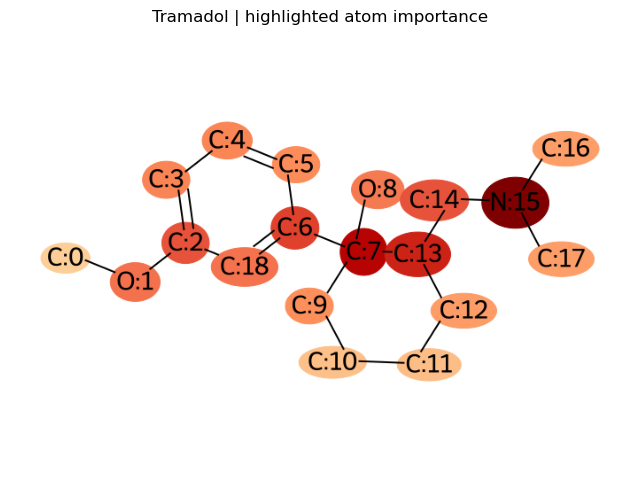

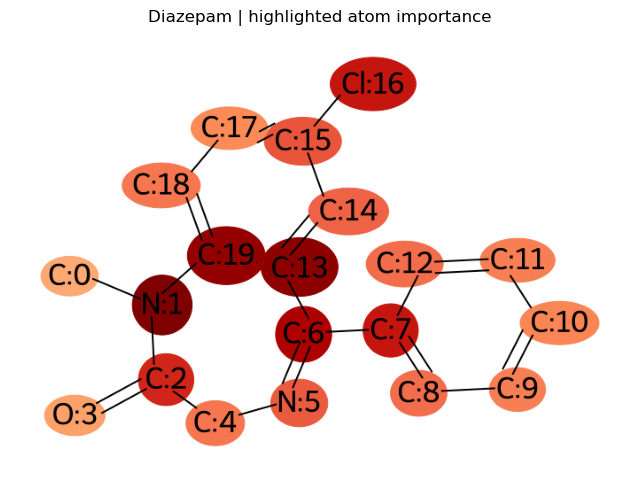

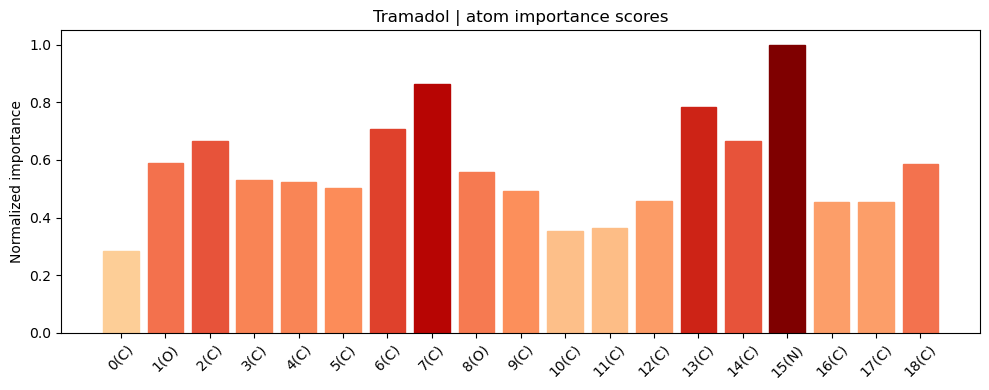

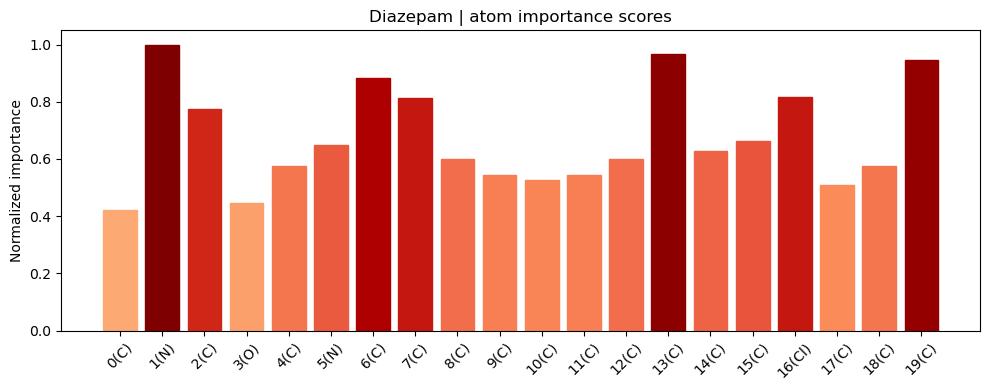

{'text_path': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Tramadol__Diazepam_explanation.txt', 'drugA_highlight': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Tramadol__Diazepam_drugA_highlight.png', 'drugB_highlight': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Tramadol__Diazepam_drugB_highlight.png', 'drugA_bars': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Tramadol__Diazepam_drugA_bars.png', 'drugB_bars': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Tramadol__Diazepam_drugB_bars.png', 'summary_json': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Tramadol__Diazepam_summary.json'}


In [19]:
# Example 1: common names
result = explain_user_pair(
    input_a="Tramadol",
    input_b="Diazepam",
    top_k=3,
    save_outputs=True
)

print(result["saved_paths"])

Test Case 02 (Paracetamol + Phenytoin)

Resolved Drug A (smiles): N-(4-hydroxyphenyl)acetamide
SMILES A: CC(=O)Nc1ccc(O)cc1
Resolved Drug B (smiles): 5,5-diphenylimidazolidine-2,4-dione
SMILES B: O=C1NC(=O)C(c2ccccc2)(c2ccccc2)N1

--- Chemical Interpretation ---

Drug A: N-(4-hydroxyphenyl)acetamide
Drug B: 5,5-diphenylimidazolidine-2,4-dione

Predicted pLD50: 2.3835
Predicted toxicity level: moderate toxicity

1. Model focus

Drug A important atoms:
- aromatic C sp2 degree 3 (atom 4); aromatic C sp2 degree 3 (atom 7); N sp2 degree 2 1 H (atom 3)

Drug B important atoms:
- ring C sp3 degree 4 (atom 5); ring C sp2 degree 3 (atom 3); aromatic C sp2 degree 3 (atom 12)

2. Chemical meaning of important atoms

Drug A:
- Atom 4 is an aromatic carbon, which may belong to a hydrophobic ring system. Atom 7 is an aromatic carbon, which may belong to a hydrophobic ring system. Atom 3 is a nitrogen atom, which may indicate an amine-like or heteroatom-rich reactive region.

Drug B:
- Atom 5 is a ring carbon, which may contribute to struc

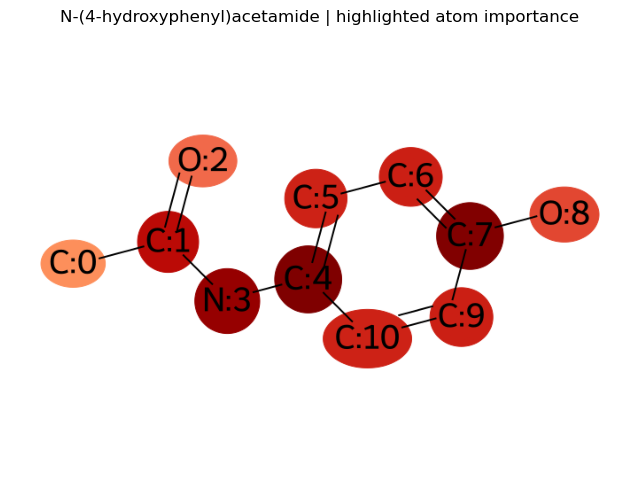

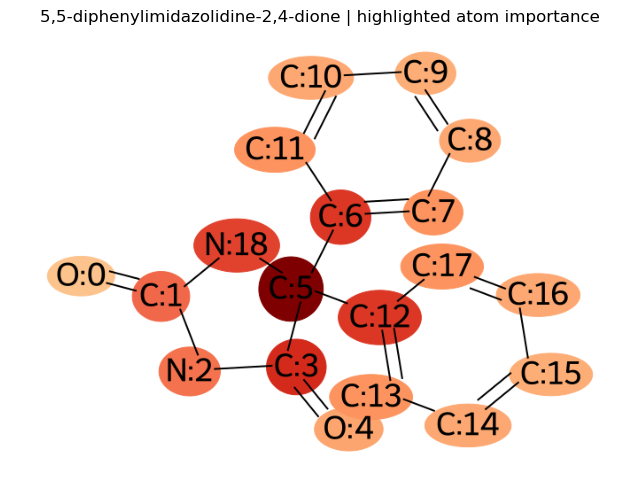

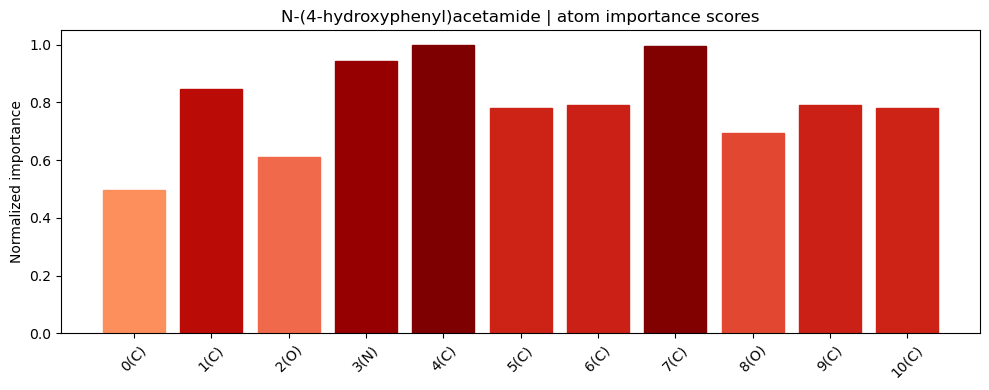

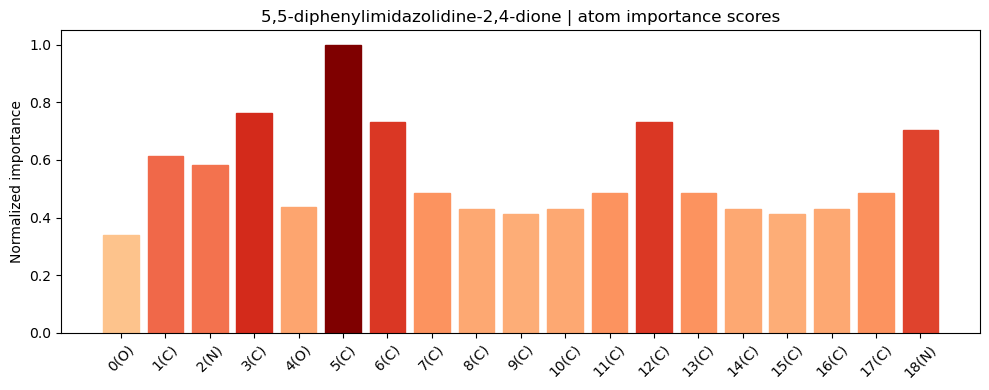

{'text_path': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\N-(4-hydroxyphenyl)acetamide__5,5-diphenylimidazolidine-2,4-_explanation.txt', 'drugA_highlight': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\N-(4-hydroxyphenyl)acetamide__5,5-diphenylimidazolidine-2,4-_drugA_highlight.png', 'drugB_highlight': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\N-(4-hydroxyphenyl)acetamide__5,5-diphenylimidazolidine-2,4-_drugB_highlight.png', 'drugA_bars': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\N-(4-hydroxyphenyl)acetamide__5,5-diphenylimidazolidine-2,4-_drugA_bars.png', 'drugB_bars': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\N-(4-hydroxyphenyl)acetamide__5,5-diphenylimidazolidine-2,4-_drugB_bars.png', 'summary_json': 'C:\\Users\\msi\\Downloads\\IRP Jupite

In [20]:
# Example 2: direct SMILES
result = explain_user_pair(
    input_a="CC(=O)NC1=CC=C(O)C=C1", # Paracetamol
    input_b="O=C1NC(=O)N(C1(C2=CC=CC=C2)C3=CC=CC=C3)", # Phenytoin
    top_k=3,
    save_outputs=True
)

print(result["saved_paths"])

Test Case 03 (Warfarin + Ibuprofen)

Enter Drug A common name or SMILES: Warfarin
Enter Drug B common name or SMILES: Ibuprofen
Resolved Drug A (name): Warfarin
SMILES A: CC(=O)CC(c1ccccc1)c1c(O)c2ccccc2oc1=O
Resolved Drug B (name): Ibuprofen
SMILES B: CC(C)Cc1ccc(C(C)C(=O)O)cc1

--- Chemical Interpretation ---

Drug A: Warfarin
Drug B: Ibuprofen

Predicted pLD50: 2.4923
Predicted toxicity level: moderate toxicity

1. Model focus

Drug A important atoms:
- aromatic O sp2 degree 2 (atom 20); aromatic C sp2 degree 3 (atom 19); aromatic C sp2 degree 3 (atom 11)

Drug B important atoms:
- C sp3 degree 3 1 H (atom 8); C sp2 degree 3 (atom 10); aromatic C sp2 degree 3 (atom 7)

2. Chemical meaning of important atoms

Drug A:
- Atom 20 is a ring oxygen, which may contribute to polarity and oxygen-containing cyclic structure. Atom 19 is an aromatic carbon, which may belong to a hydrophobic ring system. Atom 11 is an aromatic carbon, which may belong to a hydrophobic ring system.

Drug B:
- Atom 8 is a highly connected C atom, whi

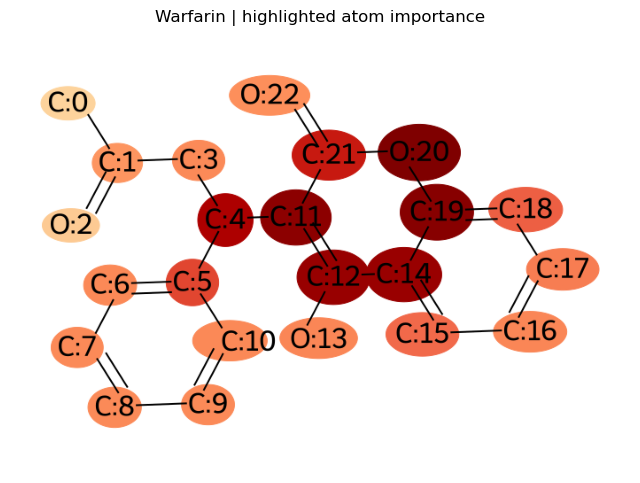

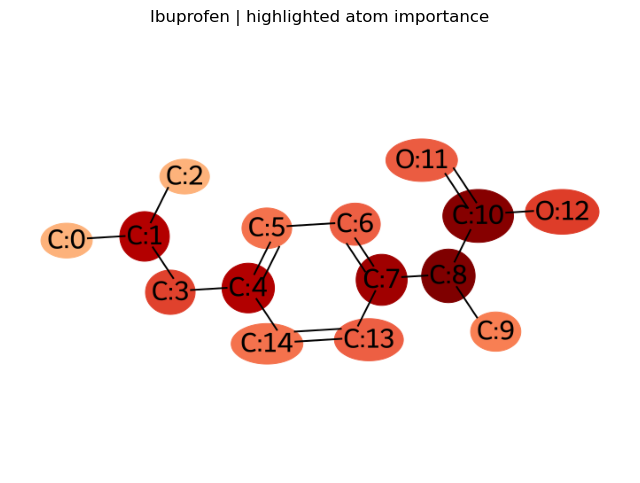

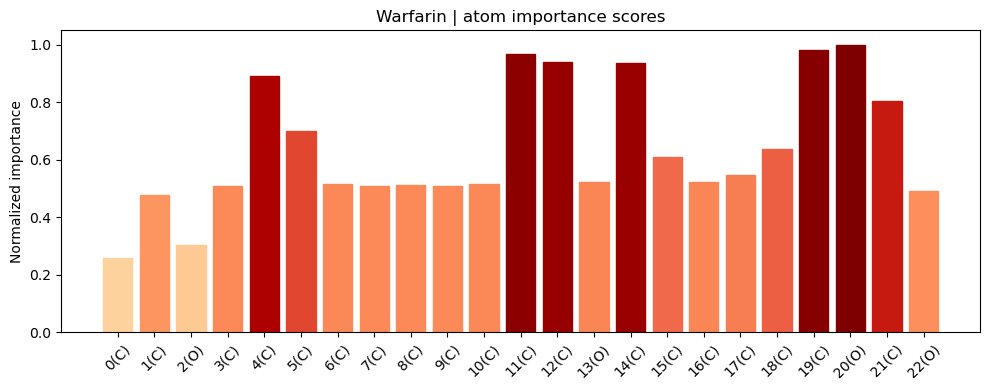

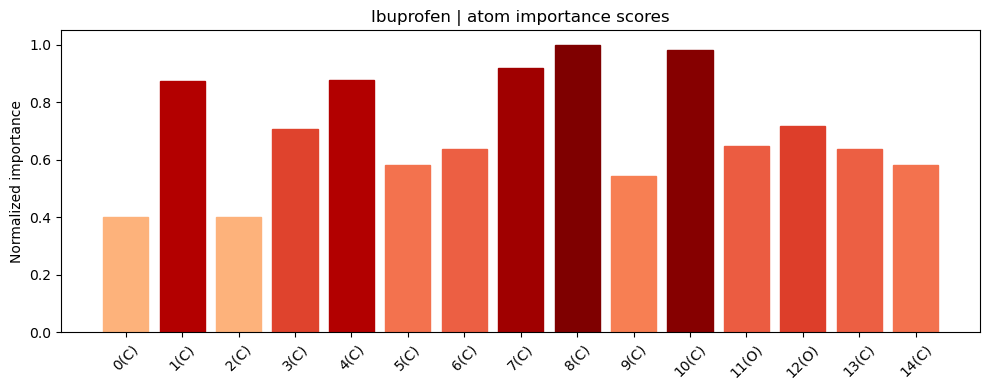


Prediction complete.
Predicted pLD50: 2.4923
Predicted toxicity level: moderate toxicity
Saved files: {'text_path': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Warfarin__Ibuprofen_explanation.txt', 'drugA_highlight': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Warfarin__Ibuprofen_drugA_highlight.png', 'drugB_highlight': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Warfarin__Ibuprofen_drugB_highlight.png', 'drugA_bars': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Warfarin__Ibuprofen_drugA_bars.png', 'drugB_bars': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Warfarin__Ibuprofen_drugB_bars.png', 'summary_json': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Warfarin__Ibuprofen_summary.json'}


In [21]:
user_input_a = input("Enter Drug A common name or SMILES: ").strip()
user_input_b = input("Enter Drug B common name or SMILES: ").strip()

result = explain_user_pair(
    input_a=user_input_a,
    input_b=user_input_b,
    top_k=3,
    save_outputs=True
)

print("\nPrediction complete.")
print("Predicted pLD50:", round(result["pred_pLD50"], 4))
print("Predicted toxicity level:", result["toxicity_level"])
print("Saved files:", result["saved_paths"])

Test Case 04 (Vitamin C + Paracetamol)

Enter Drug A common name or SMILES: Vitamin C
Enter Drug B common name or SMILES: Paracetamol
Resolved Drug A (name): Vitamin C
SMILES A: O=C1OC(C(O)CO)C(O)=C1O
Resolved Drug B (name): Paracetamol
SMILES B: CC(=O)Nc1ccc(O)cc1

--- Chemical Interpretation ---

Drug A: Vitamin C
Drug B: Paracetamol

Predicted pLD50: 1.7694
Predicted toxicity level: low toxicity

1. Model focus

Drug A important atoms:
- ring O sp2 degree 2 (atom 2); ring C sp2 degree 3 (atom 8); ring C sp2 degree 3 (atom 10)

Drug B important atoms:
- aromatic C sp2 degree 3 (atom 7); aromatic C sp2 degree 3 (atom 4); aromatic C sp2 degree 2 1 H (atom 9)

2. Chemical meaning of important atoms

Drug A:
- Atom 2 is a ring oxygen, which may contribute to polarity and oxygen-containing cyclic structure. Atom 8 is a ring carbon, which may contribute to structural rigidity. Atom 10 is a ring carbon, which may contribute to structural rigidity.

Drug B:
- Atom 7 is an aromatic carbon, which may belong to a hydrophobic ring sys

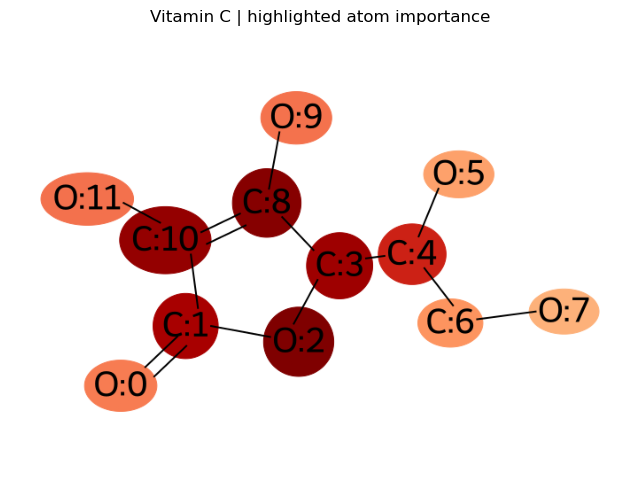

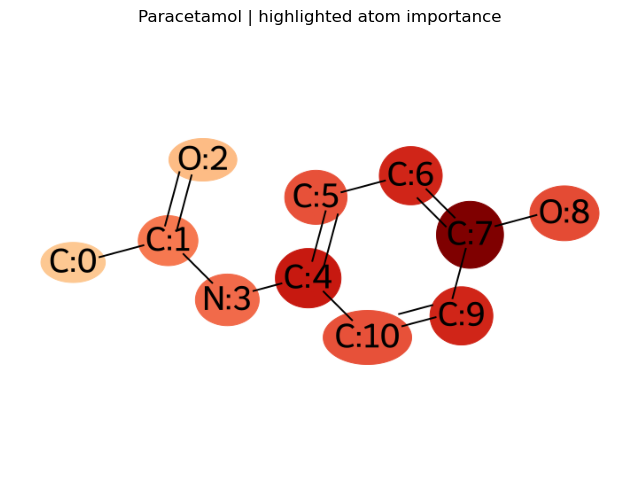

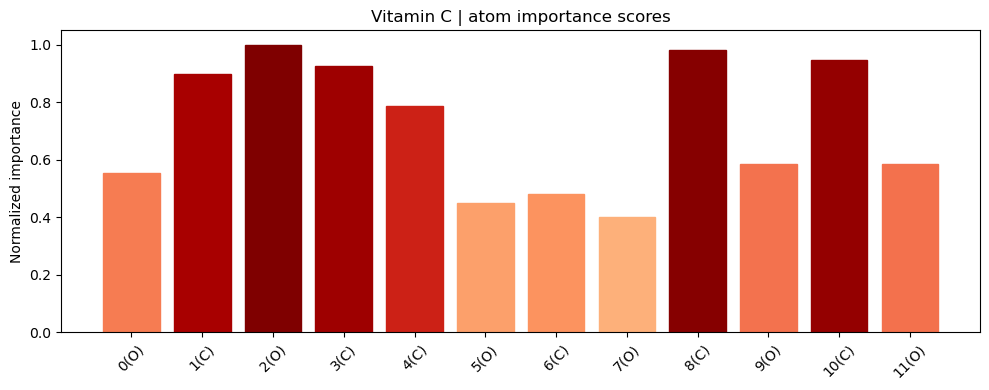

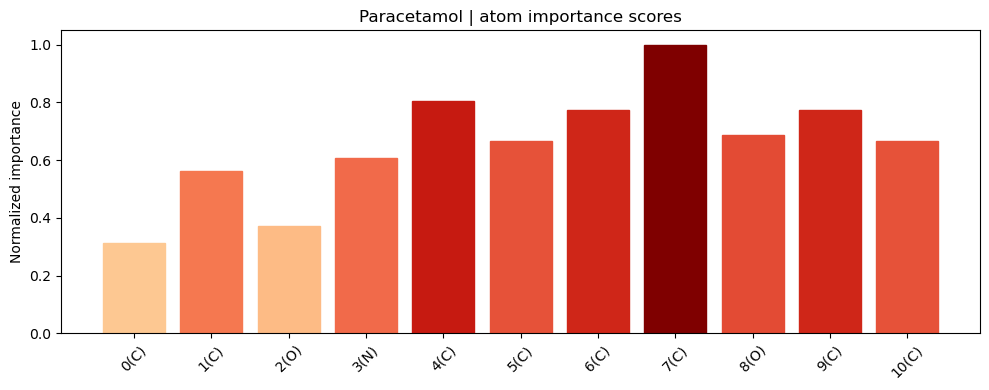


Prediction complete.
Predicted pLD50: 1.7694
Predicted toxicity level: low toxicity
Saved files: {'text_path': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Vitamin_C__Paracetamol_explanation.txt', 'drugA_highlight': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Vitamin_C__Paracetamol_drugA_highlight.png', 'drugB_highlight': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Vitamin_C__Paracetamol_drugB_highlight.png', 'drugA_bars': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Vitamin_C__Paracetamol_drugA_bars.png', 'drugB_bars': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Vitamin_C__Paracetamol_drugB_bars.png', 'summary_json': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Vitamin_C__Paracetamol_summary.json'}

In [22]:
user_input_a = input("Enter Drug A common name or SMILES: ").strip()
user_input_b = input("Enter Drug B common name or SMILES: ").strip()

result = explain_user_pair(
    input_a=user_input_a,
    input_b=user_input_b,
    top_k=3,
    save_outputs=True
)

print("\nPrediction complete.")
print("Predicted pLD50:", round(result["pred_pLD50"], 4))
print("Predicted toxicity level:", result["toxicity_level"])
print("Saved files:", result["saved_paths"])

Test Case 05 (Tramadol + Sertraline)

Enter Drug A common name or SMILES: Tramadol
Enter Drug B common name or SMILES: Sertraline
Resolved Drug A (name): Tramadol
SMILES A: COc1cccc(C2(O)CCCCC2CN(C)C)c1
Resolved Drug B (name): Sertraline
SMILES B: CNC1CCC(c2ccc(Cl)c(Cl)c2)c2ccccc21

--- Chemical Interpretation ---

Drug A: Tramadol
Drug B: Sertraline

Predicted pLD50: 2.0567
Predicted toxicity level: moderate toxicity

1. Model focus

Drug A important atoms:
- ring C sp3 degree 4 (atom 7); aromatic C sp2 degree 3 (atom 6); N sp3 degree 3 (atom 15)

Drug B important atoms:
- Cl sp3 degree 1 (atom 12); Cl sp3 degree 1 (atom 10); aromatic C sp2 degree 3 (atom 14)

2. Chemical meaning of important atoms

Drug A:
- Atom 7 is a ring carbon, which may contribute to structural rigidity. Atom 6 is an aromatic carbon, which may belong to a hydrophobic ring system. Atom 15 is a nitrogen atom, which may indicate an amine-like or heteroatom-rich reactive region.

Drug B:
- Atom 12 is a halogen atom (Cl), which may increase lipophilicit

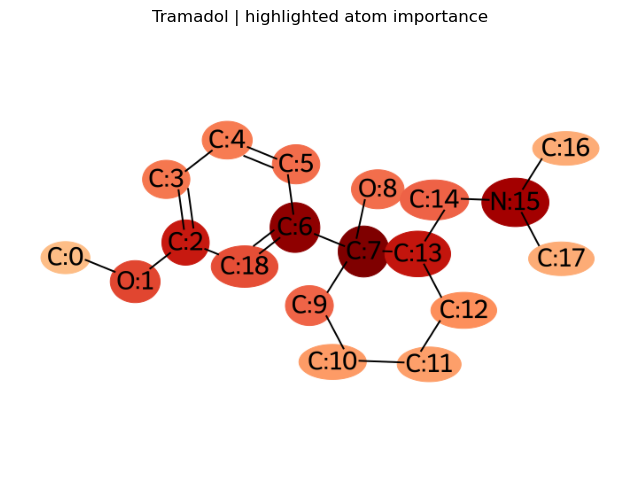

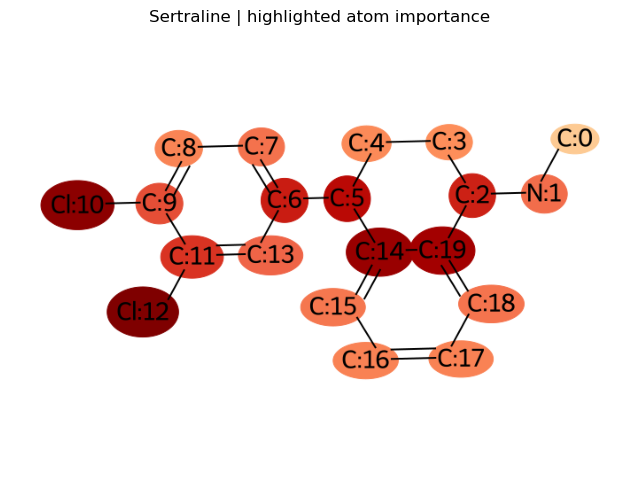

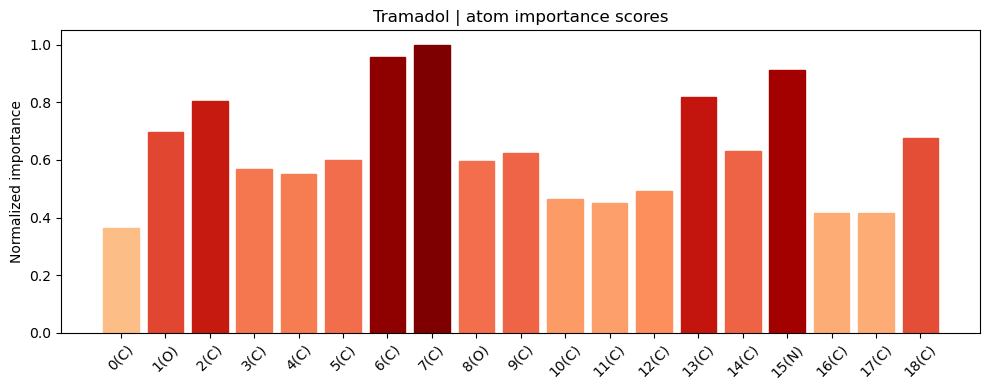

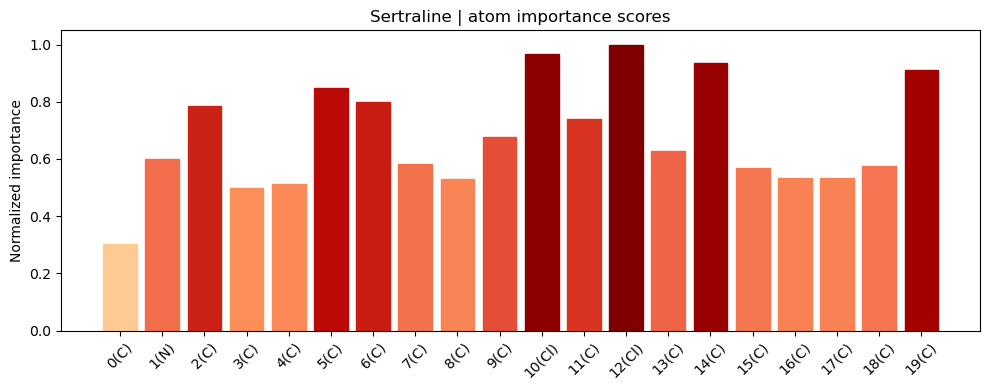


Prediction complete.
Predicted pLD50: 2.0567
Predicted toxicity level: moderate toxicity
Saved files: {'text_path': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Tramadol__Sertraline_explanation.txt', 'drugA_highlight': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Tramadol__Sertraline_drugA_highlight.png', 'drugB_highlight': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Tramadol__Sertraline_drugB_highlight.png', 'drugA_bars': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Tramadol__Sertraline_drugA_bars.png', 'drugB_bars': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Tramadol__Sertraline_drugB_bars.png', 'summary_json': 'C:\\Users\\msi\\Downloads\\IRP Jupiter nb\\Data\\processed_graphs\\user_input_explanations\\Tramadol__Sertraline_summary.json'}


In [24]:
user_input_a = input("Enter Drug A common name or SMILES: ").strip()
user_input_b = input("Enter Drug B common name or SMILES: ").strip()

result = explain_user_pair(
    input_a=user_input_a,
    input_b=user_input_b,
    top_k=3,
    save_outputs=True
)

print("\nPrediction complete.")
print("Predicted pLD50:", round(result["pred_pLD50"], 4))
print("Predicted toxicity level:", result["toxicity_level"])
print("Saved files:", result["saved_paths"])

Test Case 06

In [ ]:
user_input_a = input("Enter Drug A common name or SMILES: ").strip()
user_input_b = input("Enter Drug B common name or SMILES: ").strip()

result = explain_user_pair(
    input_a=user_input_a,
    input_b=user_input_b,
    top_k=3,
    save_outputs=True
)

print("\nPrediction complete.")
print("Predicted pLD50:", round(result["pred_pLD50"], 4))
print("Predicted toxicity level:", result["toxicity_level"])
print("Saved files:", result["saved_paths"])